<a href="https://colab.research.google.com/github/NooraZhang/Sleep-disorder-dataset-analysis/blob/main/Exploratory_Data_Analysis_and_Statistical_Reasoning_Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Project and Dataset Review

## The topic or problem you want to investigate

I want to investigate how different factors, including physical health, mental health, and sleep-related habits, affect the sleep quality of U.S. adults aged 50 years and older. Specifically, I want to investigate which factors are associated with sleep disorders among these adults.

---

## Why this topic matters

Nowadays, many people, especially older adults, experience sleep disorders. This can affect their quality of life and overall well-being. Sleep disorders may also increase the risk of other health problems among older adults. Therefore, understanding which factors are associated with sleep problems may help older adults improve their sleep quality and, in turn, improve their overall well-being.

---

## Dataset Information

**Dataset Name:**  
National Poll on Healthy Aging (NPHA)

**Original Source:**  
University of Michigan Institute for Healthcare Policy and Innovation (IHPI)

**Repository:**  
UCI Machine Learning Repository

**Dataset Link:**  
https://archive-beta.ics.uci.edu/dataset/936/national%2Bpoll%2Bon%2Bhealthy%2Baging%2B%28npha%29

---

## What does this dataset contain?

This dataset is a subset of the National Poll on Healthy Aging (NPHA) dataset. It contains information about U.S. adults aged 50 years and older, including their mental health, physical health, sleep-related habits, and other factors that may be associated with their sleep quality.

---

## Unit of Observation

Each row represents one adult.

---

# 2. Initial Exploratory Questions

### Question 1

What proportion of adults in this dataset experience sleep disorders?

### Question 2

How is age associated with sleep quality?

### Question 3

Is mental health associated with sleep quality among U.S. adults aged 50 years and older?

---
# 3.  Load the Dataset

In [77]:
import pandas as pd
!pip install -q ucimlrepo
from ucimlrepo import fetch_ucirepo
npha = fetch_ucirepo(id=936)
df = npha.data.original
print("Dataset loaded successfully!")
print(df.shape)
df.head()

Dataset loaded successfully!
(714, 15)


,Number_of_Doctors_Visited,Age,Physical_Health,Mental_Health,Dental_Health,Employment,Stress_Keeps_Patient_from_Sleeping,Medication_Keeps_Patient_from_Sleeping,Pain_Keeps_Patient_from_Sleeping,Bathroom_Needs_Keeps_Patient_from_Sleeping,Uknown_Keeps_Patient_from_Sleeping,Trouble_Sleeping,Prescription_Sleep_Medication,Race,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,1,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,4,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,4,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,1,2


# 4. Initial Dataset Review

**Number of rows:** 714

**Number of columns:** 15

---

## Column Names and Datatype

| Name | Role | Type | Units | Description | Missing Values |
|------|------|------|------|-------------|----------------|
| **Number_of_Doctors_Visited** | target | categorical | | The total count of different doctors the patient has seen = {<br>1: 0–1 doctors<br>2: 2–3 doctors<br>3: 4 or more doctors<br>} | No |
| **Age** | feature | categorical | | The patient's age group = {<br>1: 50–64<br>2: 65–80<br>} | No |
| **Physical_Health** | feature | categorical | | A self-assessment of the patient's physical well-being = {<br>-1: Refused<br>1: Excellent<br>2: Very Good<br>3: Good<br>4: Fair<br>5: Poor<br>} | No |
| **Mental_Health** | feature | categorical | | A self-evaluation of the patient's mental or psychological health = {<br>-1: Refused<br>1: Excellent<br>2: Very Good<br>3: Good<br>4: Fair<br>5: Poor<br>} | No |
| **Dental_Health** | feature | categorical | | A self-assessment of the patient's oral or dental health = {<br>-1: Refused<br>1: Excellent<br>2: Very Good<br>3: Good<br>4: Fair<br>5: Poor<br>} | No |
| **Employment** | feature | categorical | | The patient's employment status or work-related information = {<br>-1: Refused<br>1: Working full-time<br>2: Working part-time<br>3: Retired<br>4: Not working at this time<br>} | No |
| **Stress_Keeps_Patient_from_Sleeping** | feature | categorical | | Whether stress affects the patient's ability to sleep = {<br>0: No<br>1: Yes<br>} | No |
| **Medication_Keeps_Patient_from_Sleeping** | feature | categorical | | Whether medication impacts the patient's sleep = {<br>0: No<br>1: Yes<br>} | No |
| **Pain_Keeps_Patient_from_Sleeping** | feature | categorical | | Whether physical pain disturbs the patient's sleep = {<br>0: No<br>1: Yes<br>} | No |
| **Bathroom_Needs_Keeps_Patient_from_Sleeping** | feature | categorical | | Whether the need to use the bathroom affects the patient's sleep = {<br>0: No<br>1: Yes<br>} | No |
| **Uknown_Keeps_Patient_from_Sleeping** | feature | categorical | | Unidentified factors affecting the patient's sleep = {<br>0: No<br>1: Yes<br>} | No |
| **Trouble_Sleeping** | feature | categorical | | General issues or difficulties the patient faces with sleeping = {<br>2: No<br>3: Yes<br>-1: Refused<br>} | No |
| **Prescription_Sleep_Medication** | feature | categorical | | Information about any sleep medication prescribed to the patient = {<br>-1: Refused<br>1: Use regularly<br>2: Use occasionally<br>3: Do not use<br>} | No |
| **Race** | feature | categorical | | The patient's racial or ethnic background = {<br>-2: Not asked<br>-1: REFUSED<br>1: White, Non-Hispanic<br>2: Black, Non-Hispanic<br>3: Other, Non-Hispanic<br>4: Hispanic<br>5: 2+ Races, Non-Hispanic<br>} | No |
| **Gender** | feature | categorical | | The gender identity of the patient = {<br>-2: Not asked<br>-1: REFUSED<br>1: Male<br>2: Female<br>} | No |

---

## Notes about Data Quality

No missing values are found in this dataset and all data are well organized.

# 5. Summary statistics

1. **sleep counts**

In [78]:
sleep_counts = df["Trouble_Sleeping"].value_counts()
sleep_percent = df["Trouble_Sleeping"].value_counts(normalize=True) * 100

summary_sleep = pd.DataFrame({
    "Count": sleep_counts,
    "Percentage (%)": sleep_percent.round(2)
})

summary_sleep

,Count,Percentage (%)
Trouble_Sleeping,,
3,359,50.28
2,291,40.76
1,62,8.68
-1,2,0.28


2. **age**

In [79]:
# Map age codes to age groups
age_labels = {
    1: "50–64",
    2: "65–80"
}

# Replace codes with labels
age_group = df["Age"].map(age_labels)

# Count and percentage
age_counts = age_group.value_counts()
age_percent = age_group.value_counts(normalize=True) * 100

# Create summary table
summary_age = pd.DataFrame({
    "Count": age_counts,
    "Percentage (%)": age_percent.round(2)
})

summary_age.index.name = "Age Group"

summary_age

,Count,Percentage (%)
Age Group,,
65–80,714,100.0


3. **physical health**

In [80]:
physical_labels = {
    -1: "Refused",
     1: "Excellent",
     2: "Very Good",
     3: "Good",
     4: "Fair",
     5: "Poor"
}


physical_health = df["Physical_Health"].map(physical_labels)

physical_counts = physical_health.value_counts()
physical_percent = physical_health.value_counts(normalize=True) * 100

summary_physical = pd.DataFrame({
    "Count": physical_counts,
    "Percentage (%)": physical_percent.round(2)
})

summary_physical.index.name = "Physical Health"

summary_physical

,Count,Percentage (%)
Physical Health,,
Good,291,40.76
Very Good,239,33.47
Fair,126,17.65
Excellent,36,5.04
Poor,21,2.94
Refused,1,0.14


4. **mental health**

In [81]:
mental_labels = {
    -1: "Refused",
     1: "Excellent",
     2: "Very Good",
     3: "Good",
     4: "Fair",
     5: "Poor"
}

mental_health = df["Mental_Health"].map(mental_labels)

mental_counts = mental_health.value_counts()
mental_percent = mental_health.value_counts(normalize=True) * 100

summary_mental = pd.DataFrame({
    "Count": mental_counts,
    "Percentage (%)": mental_percent.round(2)
})

summary_mental.index.name = "Mental Health"

summary_mental

,Count,Percentage (%)
Mental Health,,
Very Good,282,39.50
Excellent,219,30.67
Good,167,23.39
Fair,34,4.76
Refused,10,1.40
Poor,2,0.28


5. **stress**

In [82]:
stress_labels = {
    0: "No",
    1: "Yes"
}

stress_sleep = df["Stress_Keeps_Patient_from_Sleeping"].map(stress_labels)

stress_counts = stress_sleep.value_counts()
stress_percent = stress_sleep.value_counts(normalize=True) * 100

summary_stress_sleep = pd.DataFrame({
    "Count": stress_counts,
    "Percentage (%)": stress_percent.round(2)
})

summary_stress_sleep.index.name = "Stress affects sleep"

summary_stress_sleep

,Count,Percentage (%)
Stress affects sleep,,
No,537,75.21
Yes,177,24.79


# 6. Data visualizations





***1. Visualization of Physical Health***

This bar chart shows the distribution of physical health levels among participants in the dataset. It illustrates how participants rated their physical health，and shows the most common physical label within this dataset.

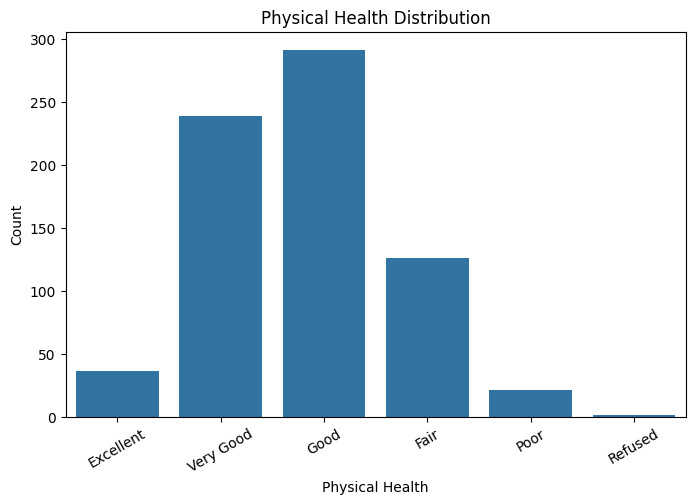

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# label mapping
physical_labels = {
    -1: "Refused",
     1: "Excellent",
     2: "Very Good",
     3: "Good",
     4: "Fair",
     5: "Poor"
}

# map data
df["Physical_Health_Label"] = df["Physical_Health"].map(physical_labels)

# plot
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Physical_Health_Label",
    order=["Excellent", "Very Good", "Good", "Fair", "Poor", "Refused"]
)

plt.title("Physical Health Distribution")
plt.xlabel("Physical Health")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

***2. Visualization of the relationship between level of physical health and sleeping quality***

 I used a bar chart and four distinct colors to show the relationship clearly.  However, there are no obvious relations between the two variables.

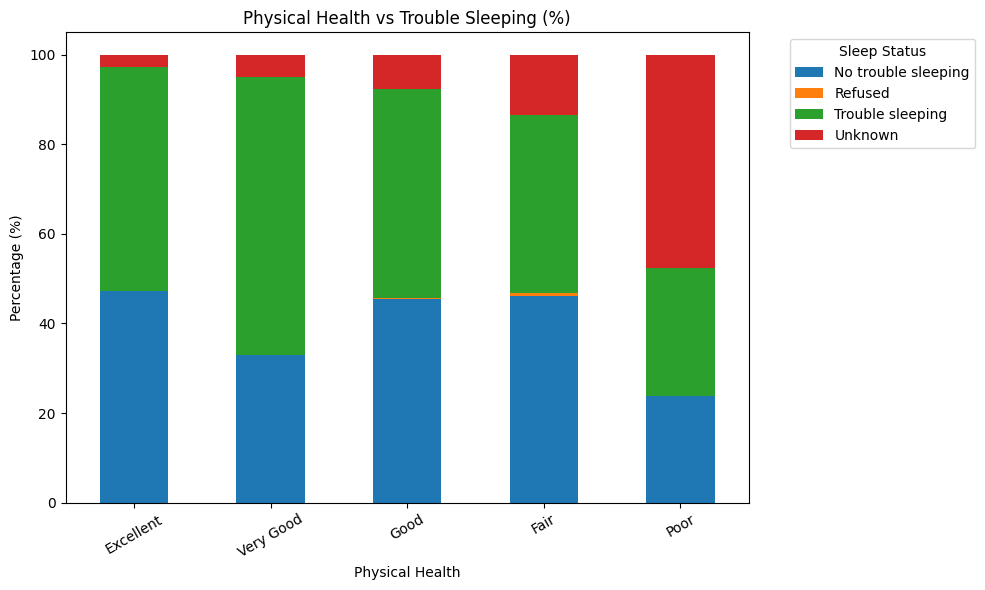

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

physical_labels = {
    -1: "Refused",
     1: "Excellent",
     2: "Very Good",
     3: "Good",
     4: "Fair",
     5: "Poor"
}

sleep_labels = {
    2: "No trouble sleeping",
    3: "Trouble sleeping",
    -1: "Refused",
    1: "Unknown"
}

df["Physical_Health_Label"] = df["Physical_Health"].map(physical_labels)
df["Trouble_Sleeping_Label"] = df["Trouble_Sleeping"].map(sleep_labels)

cross_tab = pd.crosstab(
    df["Physical_Health_Label"],
    df["Trouble_Sleeping_Label"],
    normalize="index"
) * 100

cross_tab = cross_tab.loc[
    ["Excellent", "Very Good", "Good", "Fair", "Poor"]
]

cross_tab.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Physical Health vs Trouble Sleeping (%)")
plt.xlabel("Physical Health")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=30)
plt.legend(title="Sleep Status", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

***3. Visualization of the relationship between mental health and sleeping quality***

I used a bar chart and four colors to show the relationship. As you can see in the graph, all the people who have poor mental health have the problem of sleep disorder.

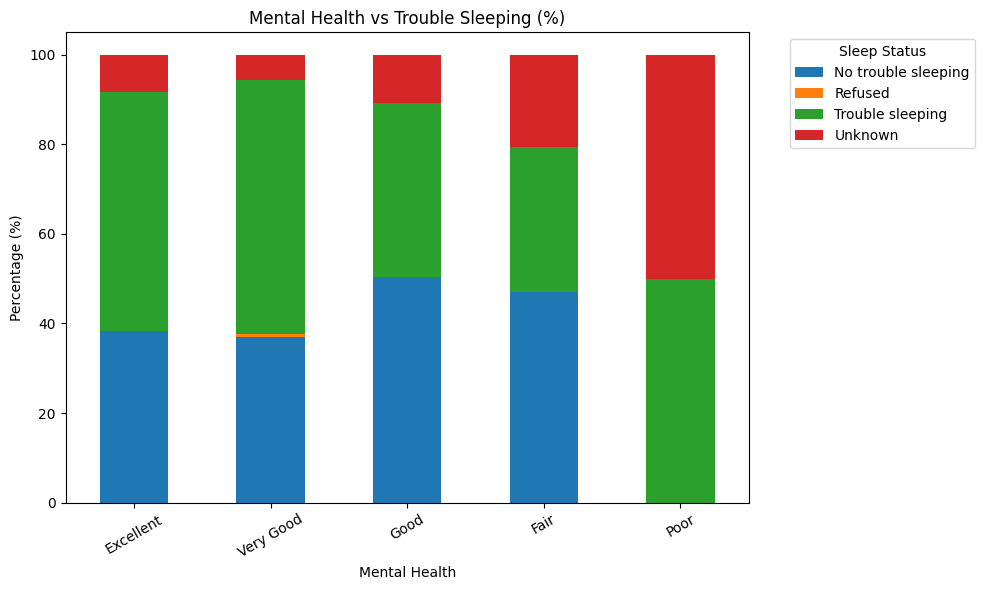

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

mental_labels = {
    -1: "Refused",
     1: "Excellent",
     2: "Very Good",
     3: "Good",
     4: "Fair",
     5: "Poor"
}

sleep_labels = {
    2: "No trouble sleeping",
    3: "Trouble sleeping",
    -1: "Refused",
    1: "Unknown"
}

df["Mental_Health_Label"] = df["Mental_Health"].map(mental_labels)
df["Trouble_Sleeping_Label"] = df["Trouble_Sleeping"].map(sleep_labels)

cross_tab_mh = pd.crosstab(
    df["Mental_Health_Label"],
    df["Trouble_Sleeping_Label"],
    normalize="index"
) * 100

cross_tab_mh = cross_tab_mh.loc[
    ["Excellent", "Very Good", "Good", "Fair", "Poor"]
]

cross_tab_mh.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Mental Health vs Trouble Sleeping (%)")
plt.xlabel("Mental Health")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=30)
plt.legend(title="Sleep Status", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

***4.Visualization of the relationship between employment status and sleeping quality***

I used a stacked bar chart with two distinct colors to show the relationship. This diagram shows that people who are not working have a mush higher proportion of sleep disorder than others.

/tmp/ipykernel_1837/4272070712.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Employment"] = df["Employment"].map({


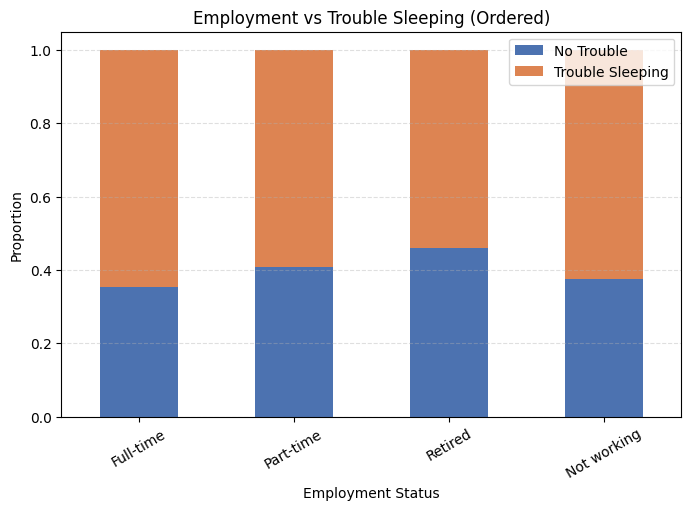

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

# 1. Load data
data = fetch_ucirepo(id=936)
df = data.data.features

# 2. Clean variables
df["Employment"] = df["Employment"].map({
    1: "Full-time",
    2: "Part-time",
    3: "Retired",
    4: "Not working"
})

# 3. Order
emp_order = ["Full-time", "Part-time", "Retired", "Not working"]

# 4. Crosstab
df["Trouble_Sleeping_Binary"] = df["Trouble_Sleeping"].map({
    3: 1,  # Trouble sleeping
    2: 0,  # No trouble sleeping
})

ct = pd.crosstab(
    df["Employment"],
    df["Trouble_Sleeping_Binary"],
    normalize="index"
)

ct = ct.reindex(emp_order)
ct = ct.reindex(columns=[0, 1])

# 5. Plot
ax = ct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["#4C72B0", "#DD8452"]
)

ax.set_title("Employment vs Trouble Sleeping (Ordered)")
ax.set_ylabel("Proportion")
ax.set_xlabel("Employment Status")
ax.legend(["No Trouble", "Trouble Sleeping"])
ax.tick_params(axis='x', rotation=30)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# 7. Preliminary EDA Findings

## What pattern do I notice?

I noticed that people with better physical health conditions tend to have a lower probability of experiencing trouble sleeping. However, this pattern is not consistent across all observations in the dataset.

---

## Employment vs sleep trouble

The proportion of sleep disorder is lowest for people who are fully employed. In contrast, the proportion of sleep disorder is relatively high among people who are unemployed or retired.

This suggests that employment status is associated with sleep quality. However, it is important to note that this does not imply causation. Employment status may be linked to other factors such as age, stress level, or health conditions.

---

## Mental health vs sleep trouble

In this dataset, individuals with poor mental health all experience sleep disorder, indicating a strong association between mental health and sleep problems.

However, the relationship between mental health and sleep trouble is not strictly linear. Participants who rated their mental status as “excellent” show a higher proportion of sleep trouble than those who rated it as “good”. This is an unusual pattern and may be due to sampling variation or the relatively small number of observations in this subgroup.

---

## What can I investigate next?

I will run a chi-square test to examine whether there is a statistically significant relationship between mental health and sleep trouble.

Although the visualization suggests a possible association, the pattern is not strictly linear and may be influenced by random variation in the dataset. Therefore, statistical testing is necessary to determine whether the observed relationship is meaningful or due to noise.

# 8. Focused Statistical Question

**Statistical Question:** Is there any significant association between mental health and sleep disorder for adults who aged 50 or above?

I want to use the chi-square independence test to investigate the association between mental health and sleep disorder. During the EDA, I found out that there is an unexpected pattern between these two variables: the people who rated their mental status as "excellent" has a larger proportion of sleep disorder than those who rated their mental status as "good". Therefore, I want to find out whether the unusual result reflects significant association, or it is just due to random noise and does not make any sense.

# 9. Statistical Test

## Name of statistical test

chi-square test

---

## Brief explanation of why the test is appropriate

This test is appropriate because mental health and sleep quality are two categorical values. Chi-square is commonly used to detect the degree of association between two categorical values. Therefore, chi-square independence test is the most appropriate test for these two variables.

---

## Null hypothesis

Mental health and sleep quality has no association for adults in USA who are 50 or above.

---

## Alternative hypothesis

Mental health and sleep quality has significant association for adults in USA who are 50 or above.

---

## Test result

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from ucimlrepo import fetch_ucirepo

# Load data
data = fetch_ucirepo(id=936)
df = data.data.features.copy()

# Employment mapping
df["Employment"] = df["Employment"].map({
    1: "Full-time",
    2: "Part-time",
    3: "Retired",
    4: "Not working"
})

# Mental Health mapping
mental_labels = {
    -1: "Refused",
     1: "Excellent",
     2: "Very Good",
     3: "Good",
     4: "Fair",
     5: "Poor"
}
df["Mental_Health_Label"] = df["Mental_Health"].map(mental_labels)

# Physical Health mapping
physical_labels = {
    -1: "Refused",
     1: "Excellent",
     2: "Very Good",
     3: "Good",
     4: "Fair",
     5: "Poor"
}
df["Physical_Health_Label"] = df["Physical_Health"].map(physical_labels)

# Chi-square test
df_filtered = df[df["Trouble_Sleeping"].isin([2, 3])].copy()

contingency = pd.crosstab(
    df_filtered["Mental_Health_Label"],
    df_filtered["Trouble_Sleeping"]
)

print("Contingency Table:")
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Contingency Table:
Trouble_Sleeping       2    3
Mental_Health_Label          
Excellent             84  117
Fair                  16   11
Good                  84   65
Poor                   0    1
Refused                3    5
Very Good            104  160

Chi-square statistic: 15.1979
p-value: 0.0095
Degrees of freedom: 5


## Interpretation

The chi-square test of independence is used to test the degree of association between two categorical values. If the p-value >= 0.05, it means that there’s insufficient evidence to conclude that there is association between the variables. If the p-value is below 0.05, it shows that there’s significant association between the variables. In my test, the p-value calculate is 0.0095, which means that there’s significant association between mental health and sleep disorder.

---

## Limitation

One limitation is that the minimum expected frequency of chi-square test for each mental status is 5, however there are only 2 people that have a ‘poor’ mental status. This situation may affect the reliability of the result.

Another limitation is that the participants who answered “unknown” or “refused” for the “trouble-sleeping” variable are excluded from this test. There might be selection bias for those people who did not answer this question and may affect the result.

# 10. Interpretation of Statistical Result

The test suggests that there’s significant association between mental health and sleep disorder. I believe that the result complicates what I saw in the visualizations. This is because in the graph shown, there is no obvious association between the two variables. However, the test suggests that the variables are highly associated. The reader should consider the bias involved in the test when interpreting the result, because the participants who answered “unknown” or “refused” were not counted in the test. This result does not support a causal claim, because it only suggests the association but not causal relationship. Sleep disorder may be caused by other factors instead of mental health.

---

# 11. Limitations and Cautions

There is some missing value in the category of ‘trouble of sleeping’, and some data are shown as ‘unknown’, which may affect the result.

The sample size of 714 is relatively small for an investigation about sleep quality, and it would be more reliable if it includes more participants.

There’s sampling bias when recording the trouble of sleeping because the people who answered ‘refused’ or ‘unknown’ might tend to have a poor sleeping quality and do not want to show this result to the public.

In addition, the sleeping quality category only contains three available choices: has sleeping problem, no sleeping problem or refuse to say. This category should be changed into a rate of 1 to 10 in order to make the investigation more valuable.

The dataset does not include any confounding variable.

This dataset is a subset of the NPHA investigation, which is a survey designed to be representative of all the people in USA. Therefore, this dataset is relatively representative.

My statistical test was developed after looking at the data and the visualizations. The analysis only supports an association between the two variables, but not the casual claim.

# 12. AI Usage

- I used ChatGPT 5.5 to help me generate the code that loads the dataset.
- I used ChatGPT 5.5 to convert my text into the Markdown format used in Google Colab.
- I used Claude Code to generate the code that visualizes the relationship between different variables.
- I used Claude Code to generate the code for the chi-square test.